# 10.3 马尔可夫链与金融市场状态建模

## 学习目标
- 理解马尔可夫链的转移矩阵和稳态分布
- 用马尔可夫链建模信用评级迁移
- 分析市场牛熊状态的转移概率
- 了解隐马尔可夫模型（HMM）的直觉


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 马尔可夫链基础

**马尔可夫性质**：未来状态只依赖于当前状态，与历史无关：
$$P(X_{t+1} = j | X_t = i, X_{t-1}, ...) = P_{ij}$$

**转移矩阵** $P$：$P_{ij}$ = 从状态 $i$ 转移到状态 $j$ 的概率
- 每行之和 = 1
- 所有元素 ≥ 0

**稳态分布** $\pi$：满足 $\pi P = \pi$ 的分布（长期各状态概率）


In [3]:
# 示例：市场三状态马尔可夫链
# 状态：0=熊市, 1=震荡, 2=牛市
P = np.array([
    [0.70, 0.20, 0.10],  # 熊市: 70%继续熊, 20%震荡, 10%牛市
    [0.15, 0.70, 0.15],  # 震荡: 对称
    [0.05, 0.25, 0.70],  # 牛市: 70%继续牛
])
states = ['熊市', '震荡', '牛市']
P_df = pd.DataFrame(P, index=states, columns=states)
print('市场状态转移矩阵 P:')
print(P_df.round(3).to_string())

# 计算稳态分布（求解 πP = π, sum(π) = 1）
eigenvalues, eigenvectors = np.linalg.eig(P.T)
pi = eigenvectors[:, np.argmin(np.abs(eigenvalues - 1))].real
pi = np.abs(pi) / np.abs(pi).sum()
print(f'\n稳态分布 π:')
for s, p in zip(states, pi):
    print(f'  {s}: {p:.3f} ({p:.1%})')


市场状态转移矩阵 P:
      熊市    震荡    牛市
熊市  0.70  0.20  0.10
震荡  0.15  0.70  0.15
牛市  0.05  0.25  0.70

稳态分布 π:
  熊市: 0.266 (26.6%)
  震荡: 0.430 (43.0%)
  牛市: 0.304 (30.4%)


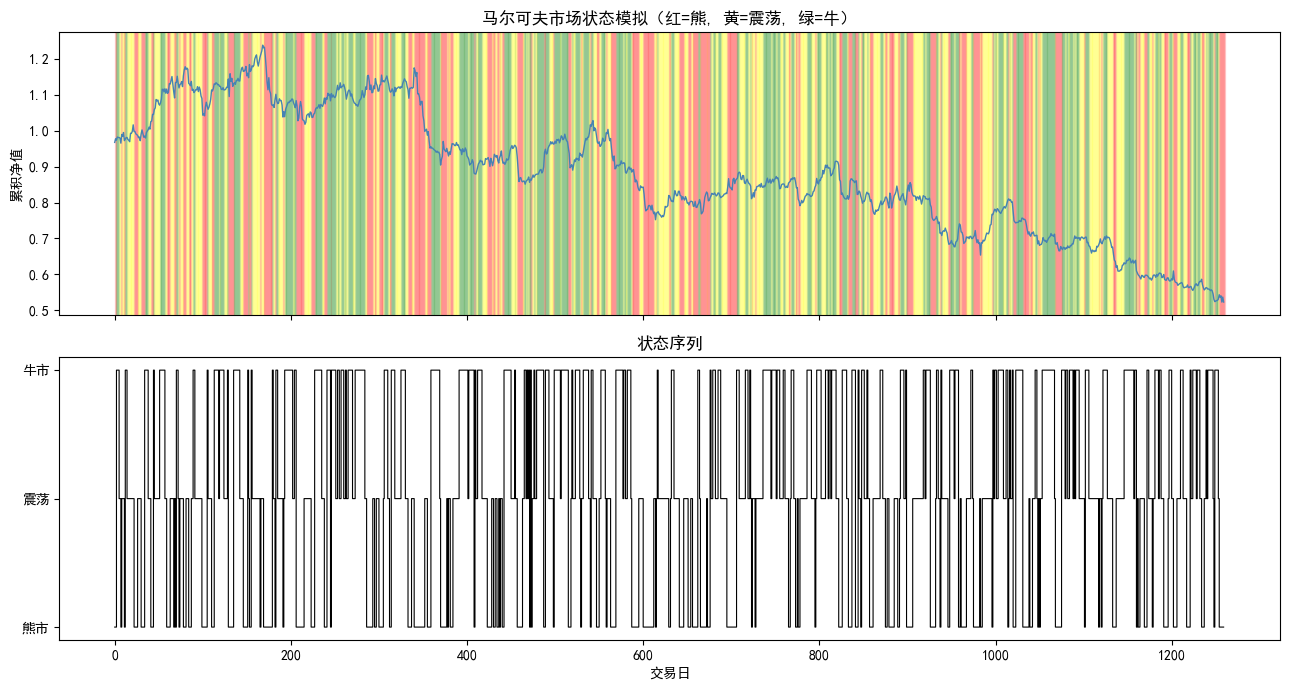

In [4]:
# 模拟马尔可夫链状态序列
state = 0  # 从熊市开始
state_seq = [state]
for _ in range(252 * 5 - 1):
    state = np.random.choice(3, p=P[state])
    state_seq.append(state)

state_seq = np.array(state_seq)

# 对应各状态的市场收益率参数
state_params = {0: (-0.0008, 0.02), 1: (0.0002, 0.01), 2: (0.001, 0.008)}
returns = np.array([np.random.normal(*state_params[s]) for s in state_seq])
cum_returns = (1 + pd.Series(returns)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
cum_returns.plot(ax=axes[0], color='steelblue', lw=1)
cmap = {0: 'red', 1: 'yellow', 2: 'green'}
for t in range(len(state_seq)):
    axes[0].axvspan(t, t+1, alpha=0.15, color=cmap[state_seq[t]])
axes[0].set_title('马尔可夫市场状态模拟（红=熊, 黄=震荡, 绿=牛）'); axes[0].set_ylabel('累积净值')

pd.Series(state_seq).plot(ax=axes[1], color='black', lw=0.8, drawstyle='steps-post')
axes[1].set_yticks([0,1,2]); axes[1].set_yticklabels(['熊市','震荡','牛市'])
axes[1].set_title('状态序列'); axes[1].set_xlabel('交易日')
plt.tight_layout(); plt.show()


## 2. 信用评级迁移矩阵（标准普尔实证）

马尔可夫链最重要的金融应用之一：**信用评级迁移矩阵**。
描述了债券从一个信用等级迁移到另一个等级（包括违约 D）的年概率。


In [5]:
# 标准普尔简化年度信用迁移矩阵（近似历史数据）
ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'D']
P_credit = np.array([
    [0.9111, 0.0788, 0.0071, 0.0006, 0.0000, 0.0000, 0.0000+0.0024],  # AAA
    [0.0070, 0.9065, 0.0779, 0.0064, 0.0006, 0.0011, 0.0005],  # AA
    [0.0009, 0.0227, 0.9105, 0.0530, 0.0074, 0.0026, 0.0029],  # A
    [0.0002, 0.0033, 0.0595, 0.8693, 0.0530, 0.0117, 0.0030],  # BBB
    [0.0003, 0.0014, 0.0067, 0.0773, 0.8053, 0.0862, 0.0228],  # BB
    [0.0000, 0.0011, 0.0024, 0.0043, 0.0648, 0.8346, 0.0928],  # B
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],  # D（违约吸收态）
])
# 调整行归一化
for i in range(len(ratings)-1):
    P_credit[i] = P_credit[i] / P_credit[i].sum()

P_credit_df = pd.DataFrame(P_credit, index=ratings, columns=ratings)
print('信用评级年度迁移矩阵 (%):' )
print((P_credit_df * 100).round(2).to_string())

# 5 年后的违约概率（矩阵乘幂）
P5 = np.linalg.matrix_power(P_credit, 5)
print(f'\n5 年后各级别累积违约概率:')
for r, d in zip(ratings, P5[:, -1]):
    print(f'  {r}: {d:.4f} ({d:.2%})')


信用评级年度迁移矩阵 (%):
       AAA     AA      A    BBB     BB      B       D
AAA  91.11   7.88   0.71   0.06   0.00   0.00    0.24
AA    0.70  90.65   7.79   0.64   0.06   0.11    0.05
A     0.09   2.27  91.05   5.30   0.74   0.26    0.29
BBB   0.02   0.33   5.95  86.93   5.30   1.17    0.30
BB    0.03   0.14   0.67   7.73  80.53   8.62    2.28
B     0.00   0.11   0.24   0.43   6.48  83.46    9.28
D     0.00   0.00   0.00   0.00   0.00   0.00  100.00

5 年后各级别累积违约概率:
  AAA: 0.0109 (1.09%)
  AA: 0.0058 (0.58%)
  A: 0.0184 (1.84%)
  BBB: 0.0335 (3.35%)
  BB: 0.1370 (13.70%)
  B: 0.3484 (34.84%)
  D: 1.0000 (100.00%)


## 🎯 练习

1. 计算 A 级债券从现在开始，在未来 3 年内升到 AAA 的累积概率（用矩阵幂次）。
2. 基于信用迁移矩阵，设计一个信用策略：买入 BB 级债券（若升至 BBB 则获得价差收益），计算期望收益。
3. 研究 hmmlearn 的 GaussianHMM，用真实 VIX 数据拟合 2 状态和 3 状态 HMM 的对数似然，哪个更合适？

---
**下一节** → `04_mle_estimation.ipynb`